# **Installing Required Libraries and Dependencies For The Project**

In [ ]:
%%capture
!pip install transformers datasets torch
!pip install pandas
!pip install scikit-learn
!pip install tqdm
!pip install numpy
!pip install SPARQLWrapper
!pip install rdflib
!pip install requests
!pip install openai
!pip install owlready2
!pip install ray
!pip install matplotlib
!pip install umap-learn
!pip uninstall openai
!pip install openai==0.28

# **Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import logging
import rdflib
import umap.umap_ as umap
import openai
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from scipy.stats import scoreatpercentile
from scipy.spatial.distance import pdist
from tqdm import tqdm
from rdflib import Graph, URIRef, RDF, RDFS, OWL
from nltk.probability import FreqDist
from google.colab import drive
from transformers import EarlyStoppingCallback, AutoTokenizer, AutoModelForMaskedLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling, DistilBertForMaskedLM, DistilBertTokenizer, DistilBertModel
from itertools import combinations
from owlready2 import get_ontology, ThingClass, Or, OwlReadyOntologyParsingError
from ray import tune
from datasets import Dataset, DatasetDict

# **Input Data Preparation**


*   Extracting RDF tuples from .owl files + Context Information
*   Creating the Context Sentence
*   Analyzing the final dataset's statitstical characteristics



In [ ]:
class OntologyParser:
    @staticmethod
    def extract_class_name(iri):
        """
        Extract the class name from the IRI.

        Args:
            iri (str): IRI of the class or property.

        Returns:
            str: Extracted class name.
        """
        return iri.split('#')[-1] if '#' in iri else iri.split('/')[-1]

    @staticmethod
    def extract_annotations(graph, iri, annotation_property):
        """
        Extract specific annotations (labels or comments if available) for a given IRI.

        Args:
            graph (rdflib.Graph): RDF graph.
            iri (rdflib.URIRef): IRI of the subject.
            annotation_property (rdflib.URIRef): Annotation property to query (rdfs:label, rdfs:comment).

        Returns:
            str: Annotation value, or None if not found.
        """
        return next(graph.objects(subject=iri, predicate=annotation_property), None)

    @staticmethod
    def extract_triples_with_annotations(ontology_list_path, domain):
        """
        Parse ontology files and extract RDF triples into a structured DataFrame, including labels and comments.

        Args:
            ontology_list_path (str): Path to a file containing ontology file paths.
            domain (str): The domain of the ontology for contextual Information (Computational, Machine Learning ...).

        Returns:
            pd.DataFrame: DataFrame containing RDF triples with context information.
        """
        import rdflib.namespace

        base_directory = os.path.dirname(os.path.abspath(ontology_list_path))

        # Read ontology file paths
        with open(ontology_list_path, "r") as file:
            ontology_paths = [os.path.join(base_directory, line.strip()) for line in file if line.strip()]

        if not ontology_paths:
            raise ValueError(f"No ontology files found in {ontology_list_path}")

        # Initialize storage for triples
        triples = []

        for ontology_path in ontology_paths:
            graph = rdflib.Graph()
            try:
                # Try parsing the file with auto-detected format
                graph.parse(ontology_path, format=None)
                print(f"Successfully processed: {ontology_path}")
            except Exception as e:
                print(f"Error parsing {ontology_path}: {e}")
                continue

            # Namespaces for annotations
            RDFS = rdflib.namespace.RDFS
            OWL = rdflib.namespace.OWL

            # Extract triples and annotations
            for subj, pred, obj in graph:
                subj_label = OntologyParser.extract_annotations(graph, subj, RDFS.label)
                subj_comment = OntologyParser.extract_annotations(graph, subj, RDFS.comment)
                obj_label = OntologyParser.extract_annotations(graph, obj, RDFS.label)
                obj_comment = OntologyParser.extract_annotations(graph, obj, RDFS.comment)

                triples.append({
                    "Subject Class": OntologyParser.extract_class_name(str(subj)),
                    "Subject Label": str(subj_label) if subj_label else None,
                    "Subject Comment": str(subj_comment) if subj_comment else None,
                    "Predicate": OntologyParser.extract_class_name(str(pred)),
                    "Object Class": OntologyParser.extract_class_name(str(obj)),
                    "Object Label": str(obj_label) if obj_label else None,
                    "Object Comment": str(obj_comment) if obj_comment else None,
                    "Domain": domain,
                    "Ontology Source": os.path.basename(ontology_path)
                })

        # Convert triples to a DataFrame
        rdf_df = pd.DataFrame(triples)
        return rdf_df

In [ ]:
ontology_list_path = "Add Path to .txt file with ontology paths"
output_file = "Add Path to .csv OutputFile"
domain = "Domain"

if not os.path.exists(ontology_list_path):
    print(f"Error: The file '{ontology_list_path}' does not exist.")
else:
    print(f"Starting extraction process using ontology list: {ontology_list_path}")
    triples_df = OntologyParser.extract_triples_with_annotations(ontology_list_path, domain)
    triples_df.to_csv(output_file, index=False)
    print(f"Extraction complete. Results saved to {output_file}.")

In [ ]:
class SentenceGenerator:
    @staticmethod
    def create_sentences_from_multiple_rdfs(file_paths, template=None):
        """
        Generate sentences from RDF CSV files and combine them into a single DataFrame.

        Args:
            file_paths (list): List of file paths to the CSV files containing RDF triples.
            template (str): Optional string template for sentence generation.

        Returns:
            pd.DataFrame: A DataFrame containing combined results from all files with a Sentence column.
        """
        import pandas as pd
        import os

        # Required columns in the input files
        required_columns = [
            "Subject Class", "Subject Label", "Subject Comment",
            "Predicate", "Object Class", "Object Label", "Object Comment",
            "Domain", "Ontology Source"
        ]

        # Default template for sentence generation
        if template is None:
            template = (
                "The subject '{subject}' (labeled as '{subject_label}') described as '{subject_comment}' "
                "is related to the object '{object}' (labeled as '{object_label}') described as '{object_comment}' "
                "through the predicate '{predicate}' in the domain '{domain}'."
            )

        # Initialize an empty list to store processed DataFrames
        combined_data = []

        # Process each file
        for file_path in file_paths:
            if not os.path.exists(file_path):
                print(f"File not found: {file_path}")
                continue

            try:
                # Load the CSV file with explicit dtype mapping
                dtype_mapping = {col: str for col in required_columns}
                df = pd.read_csv(file_path, dtype=dtype_mapping, low_memory=False)

                # Validate required columns
                missing_columns = [col for col in required_columns if col not in df.columns]
                if missing_columns:
                    raise ValueError(f"Missing columns in {file_path}: {', '.join(missing_columns)}")

                # Generate sentences using assign
                df = df.assign(
                    Sentence=df.apply(
                        lambda row: template.format(
                            subject=row["Subject Class"],
                            subject_label=row["Subject Label"],
                            subject_comment=row["Subject Comment"],
                            predicate=row["Predicate"],
                            object=row["Object Class"],
                            object_label=row["Object Label"],
                            object_comment=row["Object Comment"],
                            domain=row["Domain"]
                        ),
                        axis=1
                    )
                )

                # Append to the list
                combined_data.append(df)

                print(f"Processed {file_path}")

            except Exception as e:
                print(f"Error processing {file_path}: {e}")

        # Concatenate all DataFrames into one
        if combined_data:
            result_df = pd.concat(combined_data, ignore_index=True)
            return result_df
        else:
            raise ValueError("No valid data processed. Check input files for errors.")

In [ ]:
csv_files = [ "Paths to .csv Files with Extracted RDF Tuples"]

output_file = "AdjustPath/combined_sentences.csv"

try:
    combined_sentences_df = SentenceGenerator.create_sentences_from_multiple_rdfs(csv_files)
    combined_sentences_df.to_csv(output_file, index=False)
    print(f"Combined sentences saved to: {output_file}")
except Exception as e:
    print(f"An error occurred: {e}")

Processed /content/drive/MyDrive/Thesis/ReproduceMeON_Pipeline/output_data/rdf_triples_ml.csv
Processed /content/drive/MyDrive/Thesis/ReproduceMeON_Pipeline/output_data/rdf_triples_computational.csv
Processed /content/drive/MyDrive/Thesis/ReproduceMeON_Pipeline/output_data/rdf_triples_experimental.csv
Processed /content/drive/MyDrive/Thesis/ReproduceMeON_Pipeline/output_data/rdf_triples_microscopy.csv
Combined sentences saved to: /content/drive/MyDrive/Thesis/ReproduceMeON_Pipeline/output_data/combined_sentences.csv


DataFrame Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4070 entries, 0 to 4069
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Subject Class    4070 non-null   object
 1   Subject Label    2810 non-null   object
 2   Subject Comment  2600 non-null   object
 3   Predicate        4070 non-null   object
 4   Object Class     4067 non-null   object
 5   Object Label     2168 non-null   object
 6   Object Comment   2103 non-null   object
 7   Domain           4070 non-null   object
 8   Ontology Source  4070 non-null   object
 9   Sentence         4070 non-null   object
dtypes: object(10)
memory usage: 318.1+ KB
None
            Subject Class            Subject Label Subject Comment  \
0                   Point                    Point             NaN   
1  BibliographicReference  bibliographic reference             NaN   
2         kernel_function          kernel function             NaN   
3    

<ipython-input-13-c222c312342b>:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pred_names, y=pred_counts, palette="coolwarm")


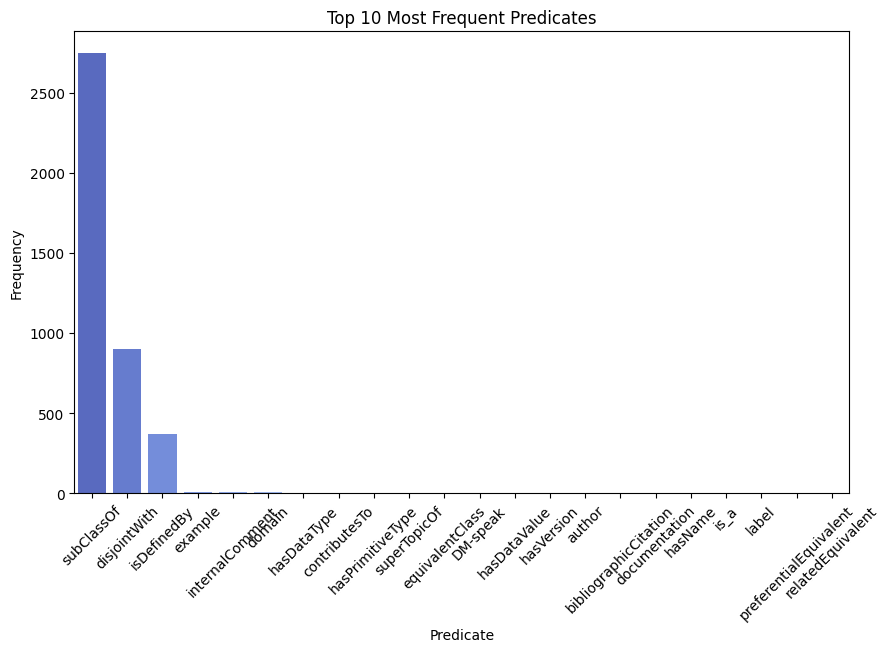


Sample Subject-Object Pairs with Predicates:
                             Subject Class     Predicate  \
3337                           WellOriginX    subClassOf   
1815                      NoiseSignalRatio    subClassOf   
475              AdministrativeInformation  disjointWith   
672                     DomainOfExperiment  disjointWith   
786                    AlgorithmAssumption  disjointWith   
3879                             LibLinear    subClassOf   
1545                              OBI:role    subClassOf   
1126                        MicroscopeType   isDefinedBy   
3939  ProjectiveFeatureExtractionAlgorithm    subClassOf   
2173                              Notebook    subClassOf   

                                Object Class  
3337                            PlateSetting  
1815                   DataSetCharacteristic  
475                                    Model  
672                            RelatedDomain  
786                                 Strategy  
3879       

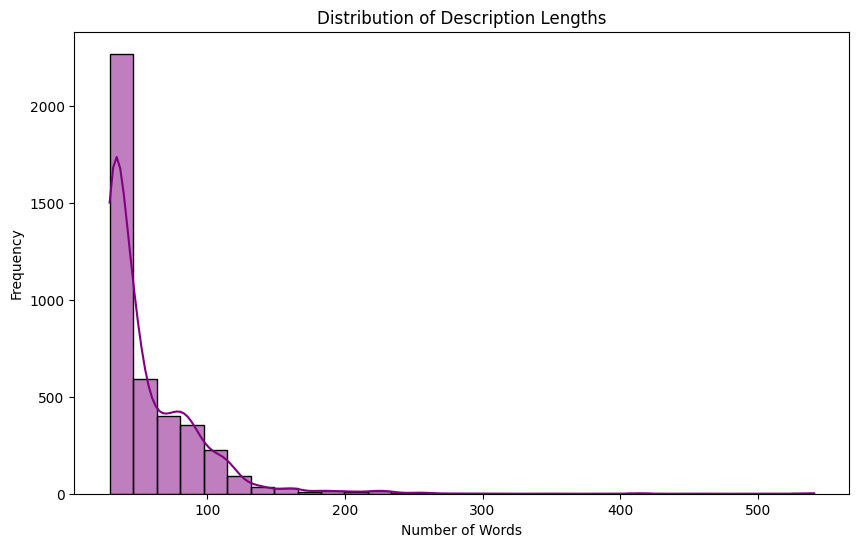


Cross-Domain Relationship Analysis:
Predicate              DM-speak  author  bibliographicCitation  contributesTo  \
Domain                                                                          
Computational                 0       0                      0              4   
Experimental workflow         0       0                      0              0   
Machine Learning              2       1                      0              0   
Microscopy                    0       0                      0              0   

Predicate              disjointWith  documentation  domain  equivalentClass  \
Domain                                                                        
Computational                     0              1       1                1   
Experimental workflow           198              0       1                1   
Machine Learning                 44              0       1                0   
Microscopy                        0              0       3                1   

P

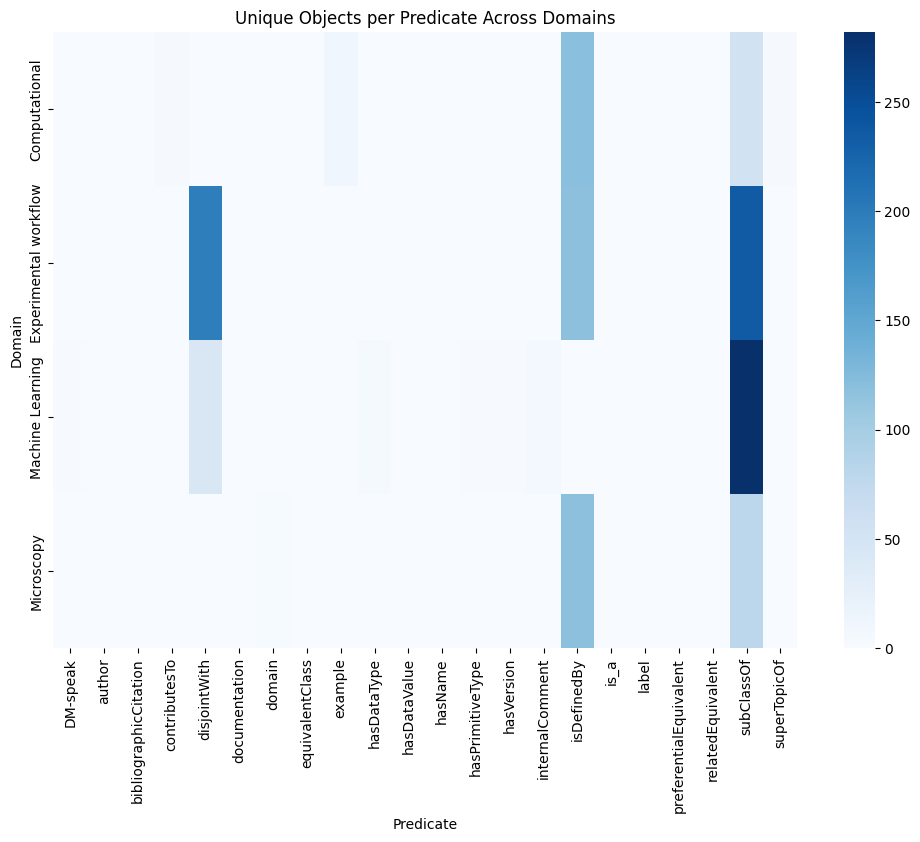

Domain
Experimental workflow    1844
Machine Learning         1150
Microscopy                595
Computational             481
Name: count, dtype: int64


<ipython-input-13-c222c312342b>:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=domain_counts.index, y=domain_counts.values, palette="viridis")


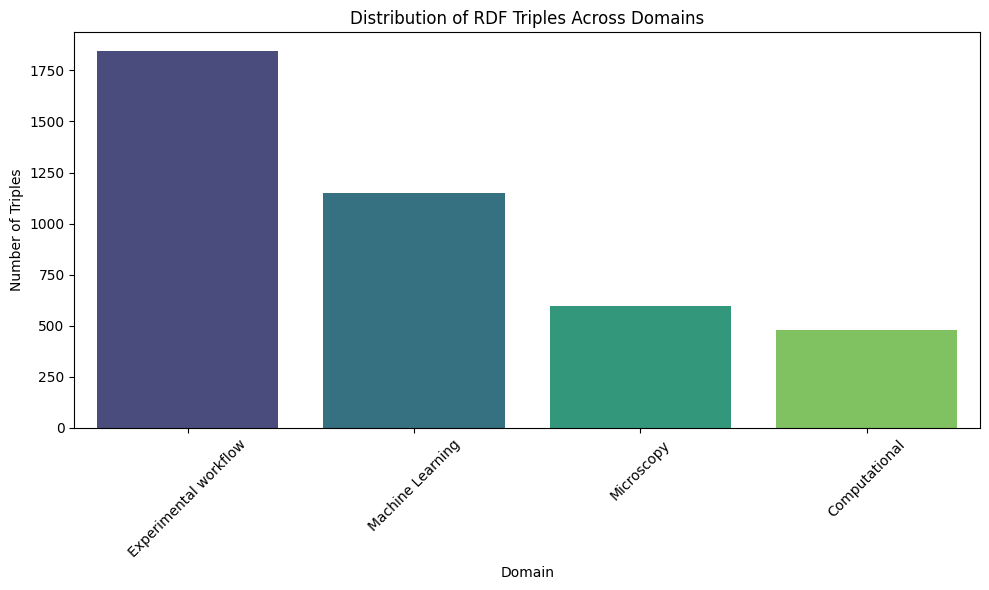

In [ ]:
combined_sentences_df =pd.read_csv("AdjustPath/combined_sentences.csv")

# Preview the data
print("DataFrame Overview:")
print(combined_sentences_df.info())
print(combined_sentences_df.head())

#Basic Statistics
print("\nBasic Statistics:")
print("Number of Rows:", len(combined_sentences_df))
print("Unique Subjects:", combined_sentences_df['Subject Class'].nunique())
print("Unique Predicates:", combined_sentences_df['Predicate'].nunique())
print("Unique Objects:", combined_sentences_df['Object Class'].nunique())

#Analyze Domain Contribution
if 'domain' in combined_sentences_df.columns:
    print("\nDomain Contribution:")
    domain_counts = combined_sentences_df['Domain'].value_counts()
    print(domain_counts)
    # Plot domain contribution
    plt.figure(figsize=(10, 6))
    sns.barplot(x=domain_counts.index, y=domain_counts.values, palette="viridis")
    plt.title("Distribution of RDF Tuples Across Domains")
    plt.ylabel("Number of Tuples")
    plt.xlabel("Domain")
    plt.xticks(rotation=45)
    plt.show()

#Analyze Predicates
print("\nMost Common Predicates:")
predicate_counts = FreqDist(combined_sentences_df['Predicate'])
most_common_predicates = predicate_counts.most_common(22)
print(most_common_predicates)

#Plot most common predicates
pred_names, pred_counts = zip(*most_common_predicates)
plt.figure(figsize=(10, 6))
sns.barplot(x=pred_names, y=pred_counts, palette="coolwarm")
plt.title("Top 10 Most Frequent Predicates")
plt.ylabel("Frequency")
plt.xlabel("Predicate")
plt.xticks(rotation=45)
plt.show()

#Analyze Subject-Object Relationships
print("\nSample Subject-Object Pairs with Predicates:")
sample_pairs = combined_sentences_df[['Subject Class', 'Predicate', 'Object Class']].sample(10)
print(sample_pairs)

#Analyze Context/Description
if 'Sentence' in combined_sentences_df.columns:
    print("\nContext Description Overview:")
    context_lengths = combined_sentences_df['Sentence'].apply(lambda x: len(str(x).split()))
    print("Average Description Length:", context_lengths.mean())
    print("Max Description Length:", context_lengths.max())
    # Plot context lengths
    plt.figure(figsize=(10, 6))
    sns.histplot(context_lengths, kde=True, color="purple", bins=30)
    plt.title("Distribution of Description Lengths")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

#Relationships Across Domains
if 'Domain' in combined_sentences_df.columns:
    print("\nCross-Domain Relationship Analysis:")
    cross_domain = combined_sentences_df.groupby(['Domain', 'Predicate'])['Object Class'].nunique().unstack(fill_value=0)
    print(cross_domain)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cross_domain, cmap="Blues", annot=False)
    plt.title("Unique Objects per Predicate Across Domains")
    plt.ylabel("Domain")
    plt.xlabel("Predicate")
    plt.show()

# Count the number of triples per domain
domain_counts = combined_sentences_df['Domain'].value_counts()
print(domain_counts)
# Plot the distribution of triples per domain
plt.figure(figsize=(10, 6))
sns.barplot(x=domain_counts.index, y=domain_counts.values, palette="viridis")
plt.title("Distribution of RDF Triples Across Domains")
plt.xlabel("Domain")
plt.ylabel("Number of Triples")
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()


# **Fine-Tuning DistilBERT**


*   Preparing Input data for the fine-tuning process by tokenizing the context sentences
*   Fine-tuning DistilBERT on the provided contextual information
*   Plotting Results of the Fine-Tuning



/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Map:   0%|          | 0/4070 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-14-6a920e528cbd>:85: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss,Validation Loss
500,1.194700,0.630509
1000,0.578100,0.413950
1500,0.422200,0.352298
2000,0.324500,0.302186
2500,0.270500,0.261234
3000,0.229800,0.287388
3500,0.211700,0.241683
4000,0.186400,0.202029
4500,0.165500,0.209581
5000,0.157100,0.188508


There were missing keys in the checkpoint model loaded: ['vocab_projector.weight'].


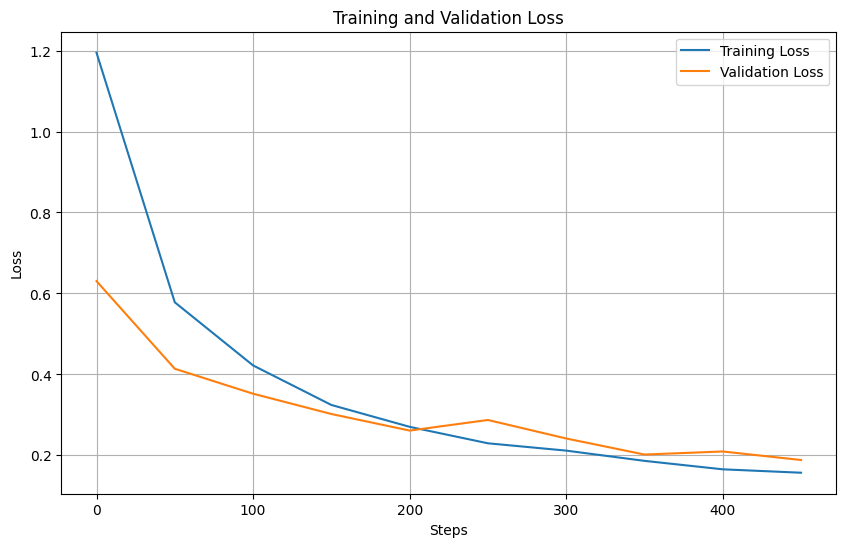

Test Metrics: {'eval_loss': 0.18291522562503815, 'eval_runtime': 1.5928, 'eval_samples_per_second': 255.532, 'eval_steps_per_second': 32.02, 'epoch': 25.0}


{'eval_loss': 0.18291522562503815,
 'eval_runtime': 1.5928,
 'eval_samples_per_second': 255.532,
 'eval_steps_per_second': 32.02,
 'epoch': 25.0}

In [ ]:
os.environ["WANDB_MODE"] = "disabled"
def prepare_dataset(sentences_df, tokenizer, split_ratios=(0.8, 0.1, 0.1)):
    """
    Prepare dataset for fine-tuning.

    Args:
        sentences_df (pd.DataFrame): DataFrame containing a 'Sentence' column.
        tokenizer: Hugging Face tokenizer.
        split_ratios (tuple): Ratios for train, validation, and test splits.

    Returns:
        DatasetDict: A DatasetDict with train, validation, and test splits.
    """
    if "Sentence" not in sentences_df.columns:
        raise ValueError("Input DataFrame must contain a 'Sentence' column.")

    dataset = Dataset.from_pandas(sentences_df[["Sentence"]].dropna())
    tokenized_dataset = dataset.map(
        lambda examples: tokenizer(
            examples["Sentence"],
            truncation=True,
            padding="max_length",
            max_length=256,
        ),
        batched=True,
    )

    # Train/Validation/Test splits
    train_test_split = tokenized_dataset.train_test_split(
        test_size=(split_ratios[1] + split_ratios[2]), seed=42
    )
    valid_test_split = train_test_split["test"].train_test_split(
        test_size=split_ratios[2] / (split_ratios[1] + split_ratios[2]), seed=42
    )

    return DatasetDict(
        {
            "train": train_test_split["train"],
            "validation": valid_test_split["train"],
            "test": valid_test_split["test"],
        }
    )


def fine_tune_model(
    model_name, tokenized_datasets, output_dir, eval_steps=50, num_epochs=3, batch_size=32
):
    """
    Fine-tune a model using Hugging Face Trainer.

    Args:
        model_name (str): Name of the pre-trained model.
        tokenized_datasets (DatasetDict): Tokenized datasets.
        output_dir (str): Directory to save the model and checkpoints.
        eval_steps (int): Number of steps between evaluations.
        num_epochs (int): Number of training epochs.
        batch_size (int): Batch size for training.

    Returns:
        Trainer: The fine-tuned trainer instance.
    """
    tokenizer = DistilBertTokenizer.from_pretrained(model_name)
    model = DistilBertForMaskedLM.from_pretrained(model_name)

    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer, mlm=True, mlm_probability=0.15
    )

    training_args = TrainingArguments(
        output_dir=output_dir,
        evaluation_strategy="steps",
        eval_steps=eval_steps,
        save_steps=eval_steps,
        logging_steps=eval_steps,
        learning_rate=5e-5,
        per_device_train_batch_size=batch_size,
        num_train_epochs=num_epochs,
        warmup_steps=500,
        save_total_limit=2,
        fp16=torch.cuda.is_available(),
        load_best_model_at_end=True,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        data_collator=data_collator,
        tokenizer=tokenizer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )

    trainer.train()
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    return trainer


def plot_losses(trainer):
    """
    Plot the training and validation losses from the training process.

    Args:
        trainer (Trainer): The trainer instance with log history.
    """
    training_logs = trainer.state.log_history
    training_loss = [log["loss"] for log in training_logs if "loss" in log]
    validation_loss = [log["eval_loss"] for log in training_logs if "eval_loss" in log]
    steps = range(0, len(training_loss) * 50, 50)  # Adjust based on eval_steps

    plt.figure(figsize=(10, 6))
    plt.plot(steps, training_loss, label="Training Loss")
    plt.plot(steps[:len(validation_loss)], validation_loss, label="Validation Loss")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()


def evaluate_test_set(trainer, tokenized_datasets):
    """
    Evaluate the model on the test set.

    Args:
        trainer (Trainer): The trained model's trainer instance.
        tokenized_datasets (DatasetDict): Tokenized datasets containing the test set.

    Returns:
        dict: Evaluation metrics on the test set.
    """
    test_metrics = trainer.evaluate(tokenized_datasets["test"])
    print("Test Metrics:", test_metrics)
    return test_metrics

# sentences_df = pd.read_csv(data_path)
model_name = "distilbert-base-uncased"
input_file = pd.read_csv("AdjustPath/combined_sentences.csv")

# Step 2: Tokenize and split dataset
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
tokenized_datasets = prepare_dataset(input_file, tokenizer)

# Step 3: Fine-tune the model
output_dir = "AdjustPath/fine_tuned_model"
trainer = fine_tune_model(
    model_name=model_name,
    tokenized_datasets=tokenized_datasets,
    output_dir=output_dir,
    eval_steps=500,
    num_epochs=25,
    batch_size=16,
)

# Step 4: Plot losses
plot_losses(trainer)

# Step 5: Evaluate on the test set
evaluate_test_set(trainer, tokenized_datasets)


# **Generating Concepts Embedding Using Fine-Tuned DistilBERT**

*   Generating Embeddings for both Subject and Object Classes taking into account their context in the ontology
*   Analyzing the statistical characteristics of the generated embeddings




In [ ]:
class EmbeddingGenerator:
    """
    Generate embeddings for subject and object concepts, explicitly taking their contextual information into account.
    """

    def __init__(self, model_path):
        """
        Initialize the EmbeddingGenerator with the fine-tuned DistilBERT model.

        Args:
            model_path (str): Path to the fine-tuned model directory.
        """
        self.tokenizer = DistilBertTokenizer.from_pretrained(model_path)
        self.model = DistilBertModel.from_pretrained(model_path).eval()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

    def _generate_batch_embeddings(self, contexts, max_length=256):
        """
        Generate embeddings for a batch of context sentences.

        Args:
            contexts (list[str]): A batch of context strings.
            max_length (int): Maximum sequence length for tokenization.

        Returns:
            np.ndarray: Numpy array of embeddings for the batch.
        """
        # Tokenize the context sentences
        inputs = self.tokenizer(
            list(contexts),
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        ).to(self.device)

        # Generate embeddings using the model
        with torch.no_grad():
            outputs = self.model(**inputs).last_hidden_state
            # Mean pooling to generate a single fixed-size embedding for each context
            embeddings = outputs.mean(dim=1).cpu().numpy()
        return embeddings

    def generate_embeddings(self, triples_df, batch_size=16):
        """
        Generate embeddings for subjects and objects, taking into account context information.

        Args:
            triples_df (pd.DataFrame): DataFrame with columns:
                - 'Subject Class', 'Subject Label', 'Subject Comment'
                - 'Predicate'
                - 'Object Class', 'Object Label', 'Object Comment'
                - 'Domain', 'Ontology Source', 'Sentence'
            batch_size (int): Batch size for embedding generation.

        Returns:
            pd.DataFrame: Updated DataFrame with 'Subject Embedding' and 'Object Embedding' columns.
        """
        # Validate input DataFrame structure
        required_columns = [
            "Subject Class", "Subject Label", "Subject Comment",
            "Predicate", "Object Class", "Object Label", "Object Comment",
            "Domain", "Ontology Source", "Sentence"
        ]
        missing_columns = [col for col in required_columns if col not in triples_df.columns]
        if missing_columns:
            raise ValueError(f"Missing required columns: {', '.join(missing_columns)}")

        # Generate 'Subject Context' and 'Object Context' sentences
        triples_df['Subject Context'] = triples_df.apply(
            lambda row: f"{row['Subject Label']} - {row['Subject Comment']}"
                        if row['Subject Label'] and row['Subject Comment']
                        else row['Subject Label'] or row['Subject Comment'],
            axis=1
        )
        triples_df['Object Context'] = triples_df.apply(
            lambda row: f"{row['Object Label']} - {row['Object Comment']}"
                        if row['Object Label'] and row['Object Comment']
                        else row['Object Label'] or row['Object Comment'],
            axis=1
        )

        # Generate embeddings for Subject Contexts
        print("Generating Subject Embeddings...")
        subject_embeddings = []
        for i in tqdm(range(0, len(triples_df), batch_size), desc="Processing Subject Batches"):
            batch_contexts = triples_df['Subject Context'].iloc[i:i + batch_size]
            subject_embeddings.append(self._generate_batch_embeddings(batch_contexts))
        triples_df['Subject Embedding'] = list(np.vstack(subject_embeddings))

        # Generate embeddings for Object Contexts
        print("Generating Object Embeddings...")
        object_embeddings = []
        for i in tqdm(range(0, len(triples_df), batch_size), desc="Processing Object Batches"):
            batch_contexts = triples_df['Object Context'].iloc[i:i + batch_size]
            object_embeddings.append(self._generate_batch_embeddings(batch_contexts))
        triples_df['Object Embedding'] = list(np.vstack(object_embeddings))

        return triples_df

In [ ]:
filetred_combined_sentences= pd.read_csv("AdjustPath/combined_sentences.csv")
generator = EmbeddingGenerator(model_path="AdjustPath/fine_tuned_model")
updated_df = generator.generate_embeddings(filetred_combined_sentences, batch_size=32)
print("DataFrame Info:")
print(updated_df.info())
print("Unique Domains:", updated_df['Domain'].unique())
print("Domain Counts:")
print(updated_df['Domain'].value_counts())

Generating Subject Embeddings...


Processing Subject Batches: 100%|██████████| 128/128 [00:11<00:00, 10.69it/s]


Generating Object Embeddings...


Processing Object Batches: 100%|██████████| 128/128 [00:09<00:00, 13.01it/s]

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4070 entries, 0 to 4069
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Subject Class      4070 non-null   object
 1   Subject Label      2810 non-null   object
 2   Subject Comment    2600 non-null   object
 3   Predicate          4070 non-null   object
 4   Object Class       4067 non-null   object
 5   Object Label       2168 non-null   object
 6   Object Comment     2103 non-null   object
 7   Domain             4070 non-null   object
 8   Ontology Source    4070 non-null   object
 9   Sentence           4070 non-null   object
 10  Subject Context    4070 non-null   object
 11  Object Context     4070 non-null   object
 12  Subject Embedding  4070 non-null   object
 13  Object Embedding   4070 non-null   object
dtypes: object(14)
memory usage: 445.3+ KB
None
Unique Domains: ['Machine Learning' 'Experimental workflow' 'Computational' '


Analyzing Subject Embeddings:
Embedding Dimensionality: 768
Number of Embeddings: 4070
Mean (first 5 dimensions): [-0.196352   -0.2609389  -0.18939306 -0.03911803  0.01733835]
Variance (first 5 dimensions): [0.04315128 0.05116609 0.06214492 0.06399503 0.17130935]
Mean Pairwise Cosine Distance: 0.48952785300919294


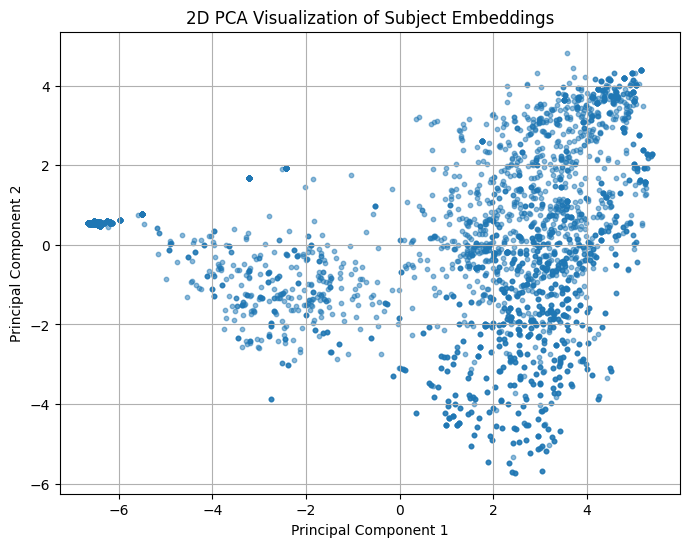

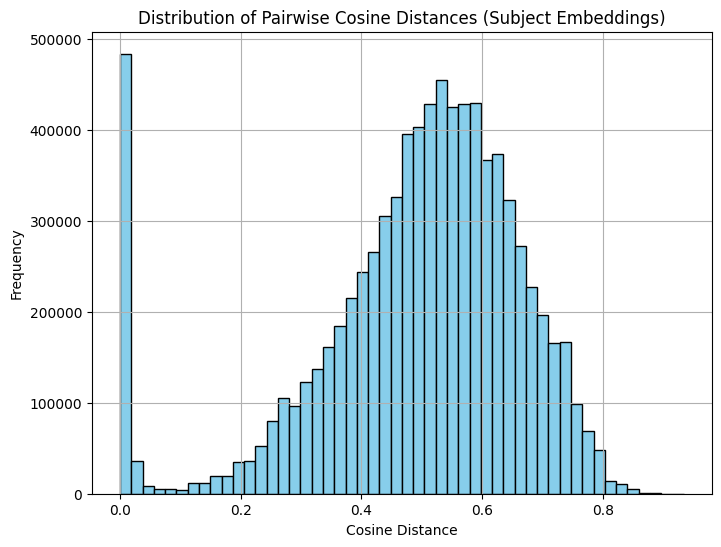


Analyzing Object Embeddings:
Embedding Dimensionality: 768
Number of Embeddings: 4070
Mean (first 5 dimensions): [-0.15469171 -0.25933203 -0.21854043 -0.10942405 -0.04406051]
Variance (first 5 dimensions): [0.04296241 0.04883615 0.05088492 0.07399086 0.20470503]
Mean Pairwise Cosine Distance: 0.4906003984841387


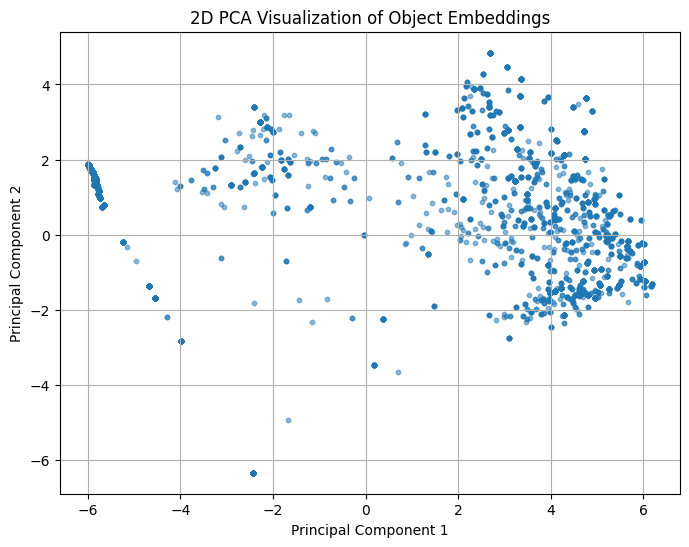

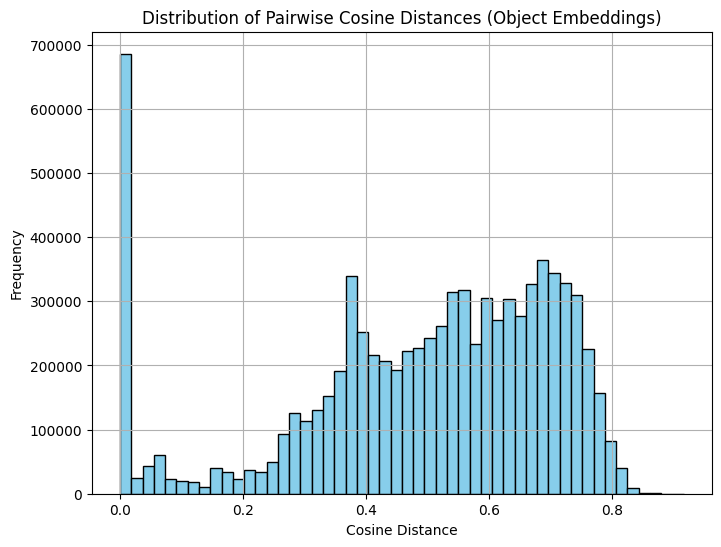

In [ ]:
# Convert embeddings to numpy arrays
subject_embeddings = np.vstack(updated_df['Subject Embedding'].values)
object_embeddings = np.vstack(updated_df['Object Embedding'].values)

# Function to analyze embeddings
def analyze_embeddings(embeddings, label):
    print(f"\nAnalyzing {label} Embeddings:")
    print(f"Embedding Dimensionality: {embeddings.shape[1]}")
    print(f"Number of Embeddings: {embeddings.shape[0]}")

    # Compute statistical properties
    embedding_mean = np.mean(embeddings, axis=0)
    embedding_variance = np.var(embeddings, axis=0)
    print(f"Mean (first 5 dimensions): {embedding_mean[:5]}")
    print(f"Variance (first 5 dimensions): {embedding_variance[:5]}")

    # Analyze pairwise distances
    pairwise_distances = pdist(embeddings, metric='cosine')
    mean_distance = np.mean(pairwise_distances)
    print(f"Mean Pairwise Cosine Distance: {mean_distance}")

    # PCA Visualization
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(embeddings)
    plt.figure(figsize=(8, 6))
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], alpha=0.5, s=10)
    plt.title(f"2D PCA Visualization of {label} Embeddings")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True)
    plt.show()

    # Histogram of pairwise distances
    plt.figure(figsize=(8, 6))
    plt.hist(pairwise_distances, bins=50, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of Pairwise Cosine Distances ({label} Embeddings)")
    plt.xlabel("Cosine Distance")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# Analyze subject and object embeddings
analyze_embeddings(subject_embeddings, "Subject")
analyze_embeddings(object_embeddings, "Object")


# **Intrinsic Analyses**


*   Find the optimal number of clusters to vizualize patterns in the generated embeddings.
*   Perform Clustering of the embeddings based on how relevant the overlapping between them is.
*   Vizualize the Clusters.


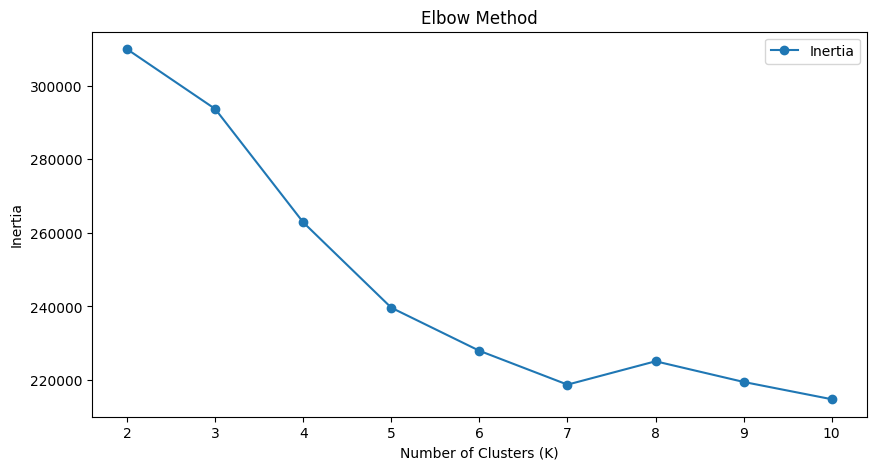

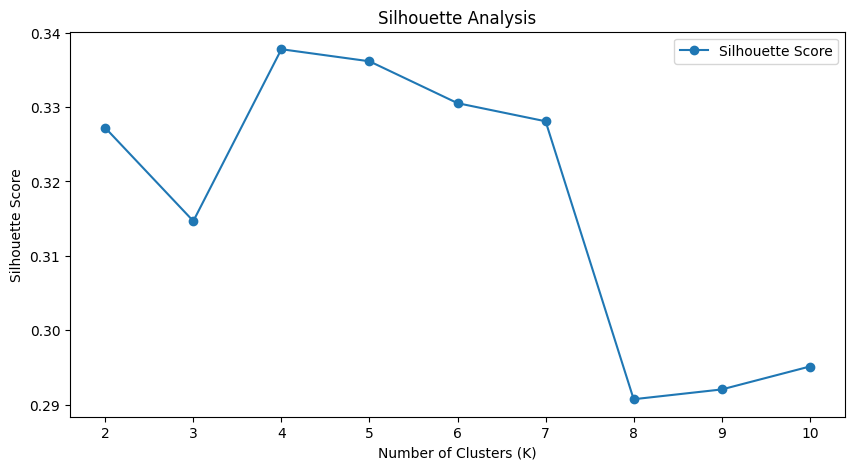

Optimal number of clusters based on silhouette score: 4
Clustering completed. Clusters assigned to the DataFrame.
Cluster 0 t-SNE plot saved to /content/drive/MyDrive/Thesis/ReproduceMeON_Pipeline/output_data/tsne_cluster_0.png


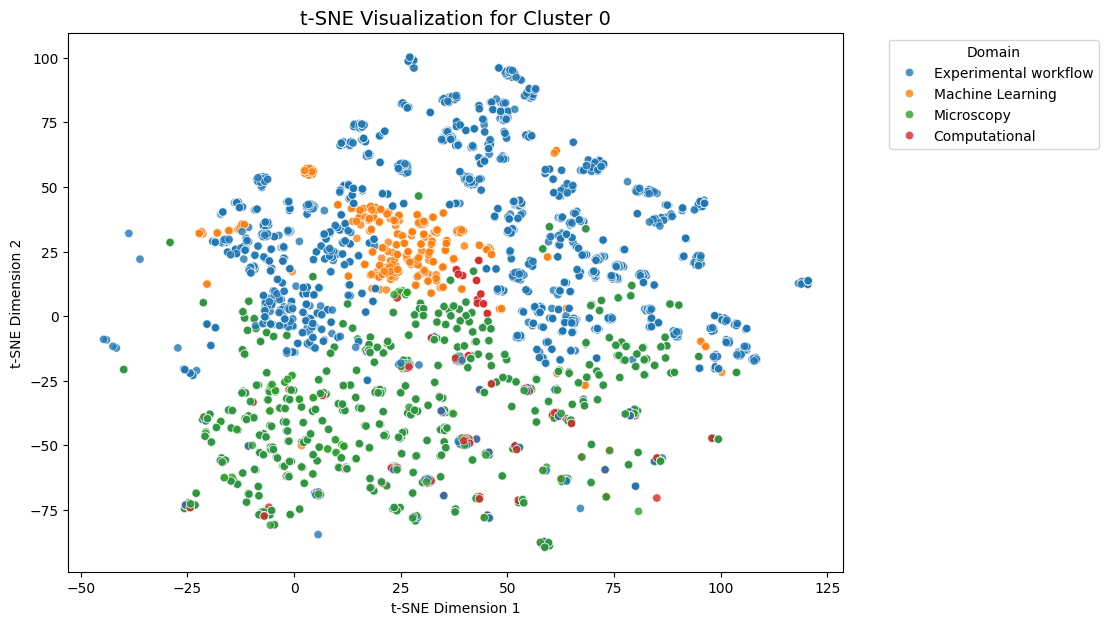

Cluster 1 t-SNE plot saved to /content/drive/MyDrive/Thesis/ReproduceMeON_Pipeline/output_data/tsne_cluster_1.png


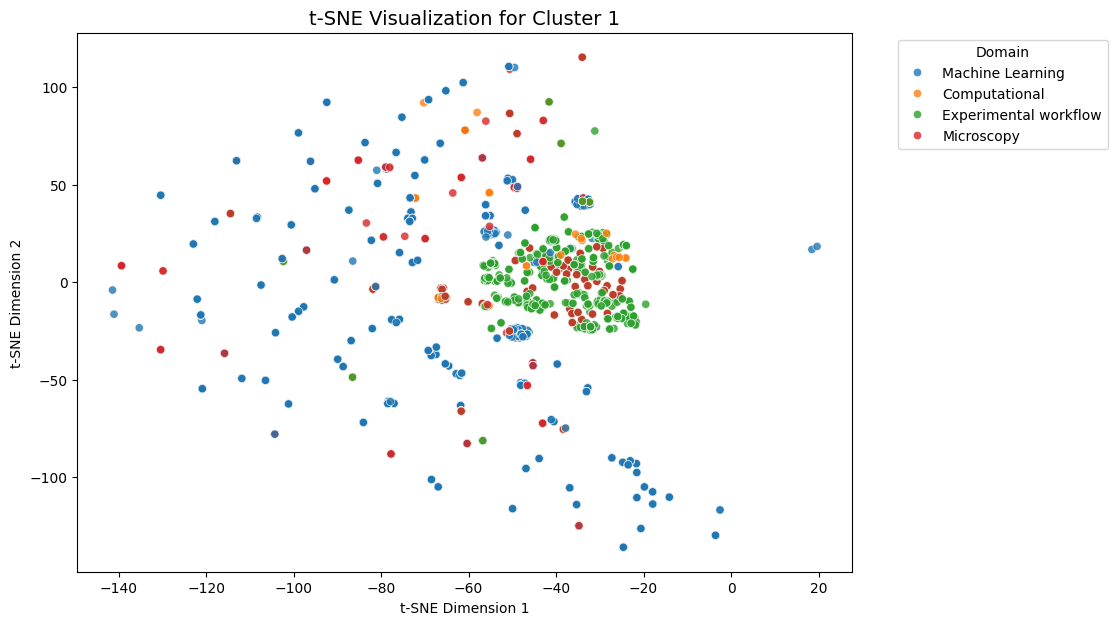

Cluster 2 t-SNE plot saved to /content/drive/MyDrive/Thesis/ReproduceMeON_Pipeline/output_data/tsne_cluster_2.png


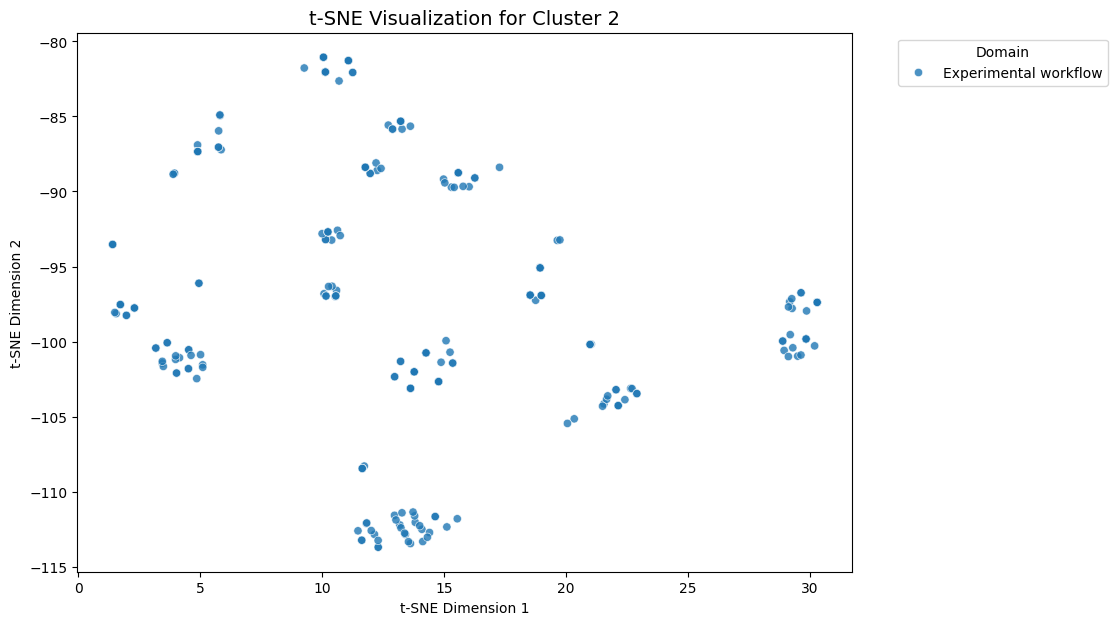

Cluster 3 t-SNE plot saved to /content/drive/MyDrive/Thesis/ReproduceMeON_Pipeline/output_data/tsne_cluster_3.png


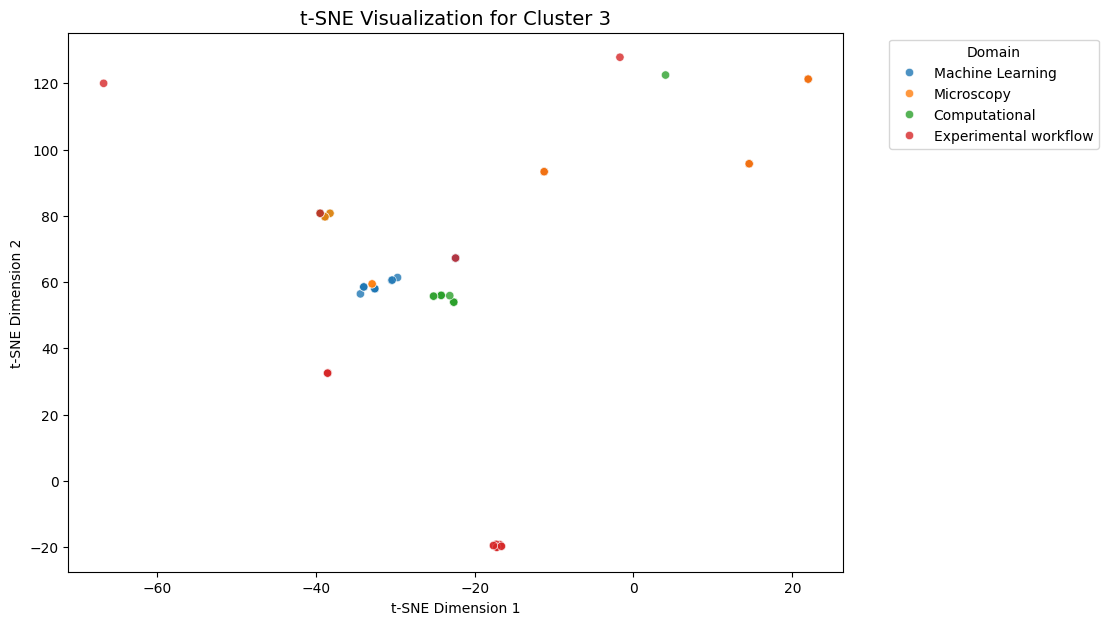

In [ ]:
class IntrinsicAnalysis:
    """
    Perform intrinsic analysis, clustering, and visualization for embeddings.
    """
    def __init__(self, n_clusters=5):
        """
        Initialize the IntrinsicAnalysis module.

        Args:
            n_clusters (int): Number of clusters for semantic grouping.
        """
        self.n_clusters = n_clusters

    def find_optimal_clusters(self, embeddings, max_clusters=10):
        """
        Find the optimal number of clusters using Elbow Method and Silhouette Score.

        Args:
            embeddings (np.ndarray): Array of embeddings.
            max_clusters (int): Maximum number of clusters to consider.

        Returns:
            int: Optimal number of clusters.
        """
        inertia = []
        silhouette_scores = []

        for k in range(2, max_clusters + 1):
            kmeans = KMeans(n_clusters=k, random_state=42)
            kmeans.fit(embeddings)
            inertia.append(kmeans.inertia_)
            silhouette_scores.append(silhouette_score(embeddings, kmeans.labels_))

        # Plot Elbow Method
        plt.figure(figsize=(10, 5))
        plt.plot(range(2, max_clusters + 1), inertia, marker='o', label='Inertia')
        plt.xlabel('Number of Clusters (K)')
        plt.ylabel('Inertia')
        plt.title('Elbow Method')
        plt.legend()
        plt.show()

        # Plot Silhouette Score
        plt.figure(figsize=(10, 5))
        plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o', label='Silhouette Score')
        plt.xlabel('Number of Clusters (K)')
        plt.ylabel('Silhouette Score')
        plt.title('Silhouette Analysis')
        plt.legend()
        plt.show()

        # Select the optimal number of clusters based on Silhouette Score
        optimal_k = np.argmax(silhouette_scores) + 2  # Adding 2 because the range starts from 2
        print(f"Optimal number of clusters based on silhouette score: {optimal_k}")
        return optimal_k

    def cluster_embeddings(self, dataframe):
        """
        Cluster embeddings across all domains and assign cluster labels.

        Args:
            dataframe (pd.DataFrame): DataFrame with 'Subject Embedding' and 'Object Embedding'.

        Returns:
            pd.DataFrame: DataFrame with added cluster labels for both subjects and objects.
        """
        # Combine all embeddings
        embeddings = np.vstack(
            dataframe['Subject Embedding'].tolist() + dataframe['Object Embedding'].tolist()
        )

        # Perform KMeans clustering
        kmeans = KMeans(n_clusters=self.n_clusters, random_state=42)
        cluster_labels = kmeans.fit_predict(embeddings)

        # Split cluster labels into subject and object clusters
        subject_cluster_labels = cluster_labels[:len(dataframe)]
        object_cluster_labels = cluster_labels[len(dataframe):]

        # Assign cluster labels to the DataFrame
        dataframe = dataframe.copy()
        dataframe["Subject Cluster"] = subject_cluster_labels
        dataframe["Object Cluster"] = object_cluster_labels
        return dataframe

    def visualize_clusters_separately(self, dataframe, save_dir=None):
        """
        Visualize clusters in separate t-SNE plots.

        Args:
            dataframe (pd.DataFrame): DataFrame containing 'Cluster', 'Domain', and 'Ontology'.
            save_dir (str, optional): Directory to save the plots. If None, the plots are not saved.
        """
        # Combine all embeddings
        embeddings = np.vstack(
            dataframe['Subject Embedding'].tolist() + dataframe['Object Embedding'].tolist()
        )

        # Use t-SNE for dimensionality reduction
        tsne = TSNE(n_components=2, random_state=42)
        tsne_results = tsne.fit_transform(embeddings)

        # Prepare metadata for plotting
        clusters = (
            dataframe["Subject Cluster"].tolist() + dataframe["Object Cluster"].tolist()
        )
        domains = (
            dataframe["Domain"].tolist() + dataframe["Domain"].tolist()
        )

        # Create a DataFrame for t-SNE results
        tsne_df = pd.DataFrame(tsne_results, columns=["t-SNE Dimension 1", "t-SNE Dimension 2"])
        tsne_df["Cluster"] = clusters
        tsne_df["Domain"] = domains

        # Plot each cluster separately
        for cluster in range(self.n_clusters):
            cluster_df = tsne_df[tsne_df["Cluster"] == cluster]
            plt.figure(figsize=(10, 7))
            sns.scatterplot(
                x="t-SNE Dimension 1",
                y="t-SNE Dimension 2",
                hue="Domain",
                palette="tab10",
                data=cluster_df,
                legend="full",
                alpha=0.8
            )
            plt.title(f"t-SNE Visualization for Cluster {cluster}", fontsize=14)
            plt.legend(title="Domain", bbox_to_anchor=(1.05, 1), loc="upper left")

            if save_dir:
                save_path = f"{save_dir}/tsne_cluster_{cluster}.png"
                plt.savefig(save_path, dpi=300, bbox_inches="tight")
                print(f"Cluster {cluster} t-SNE plot saved to {save_path}")
            plt.show()

# Example Usage
# File path for saving t-SNE visualizations
save_dir = "Ajust output path if you want to save the graphs"

# Initialize IntrinsicAnalysis
intrinsic_analyzer = IntrinsicAnalysis()

# Combine embeddings for clustering
embeddings = np.vstack(
    updated_df['Subject Embedding'].tolist() + updated_df['Object Embedding'].tolist()
)

# Step 1: Find Optimal Clusters
optimal_clusters = intrinsic_analyzer.find_optimal_clusters(embeddings, max_clusters=10)

# Step 2: Set optimal clusters and cluster embeddings
intrinsic_analyzer.n_clusters = optimal_clusters
clustered_df = intrinsic_analyzer.cluster_embeddings(updated_df)
print("Clustering completed. Clusters assigned to the DataFrame.")

# Step 3: Visualize clusters separately
intrinsic_analyzer.visualize_clusters_separately(clustered_df, save_dir=save_dir)


# **Similarity Computation - Cosine Similarity**



*   Filter out embeddings based on the relevance in the cluster
*   Compute Pair-wise similarity using cosine-similarity
*   Filter out irrelevant pairs based on dynamic thresholding technique



In [ ]:
class SimilarityMeasurement:
    """
    Measure cosine similarity between embeddings and generate meaningful pairs, optimized using cluster information.
    """

    @staticmethod
    def compute_dynamic_threshold(similarity_matrix):
        """
        Compute a dynamic threshold based on the distribution of similarity scores.

        Args:
            similarity_matrix (np.array): Pairwise cosine similarity matrix.

        Returns:
            float: Dynamically computed threshold.
        """
        # Flatten the similarity matrix and ignore diagonal (self-similarity)
        flattened_similarities = similarity_matrix[np.triu_indices(similarity_matrix.shape[0], k=1)]

        # Compute the 90th percentile similarity score
        dynamic_threshold = scoreatpercentile(flattened_similarities, 90)  # Set to 90th percentile, adjust as needed
        return dynamic_threshold

    @staticmethod
    def compute_similarity_with_clusters(dataframe, dynamic_threshold=False):
        """
        Compute similarity scores between embeddings only within the same cluster.

        Args:
            dataframe (pd.DataFrame): Input DataFrame containing 'Subject Embedding', 'Object Embedding', and cluster labels.
            dynamic_threshold (bool): Flag to use dynamic threshold or not.

        Returns:
            pd.DataFrame: DataFrame with meaningful pairs and similarity scores.
        """
        pairs_data = []

        # Group by clusters
        grouped = dataframe.groupby("Subject Cluster")

        # Iterate over each cluster
        for cluster, group in grouped:
            print(f"Processing Cluster {cluster} with {len(group)} elements...")

            # Reset index to ensure proper alignment
            group = group.reset_index(drop=True)

            # Combine embeddings within the cluster
            subject_embeddings = np.vstack(group['Subject Embedding'].tolist())
            object_embeddings = np.vstack(group['Object Embedding'].tolist())

            # Compute pairwise cosine similarity within the cluster
            similarity_matrix = cosine_similarity(subject_embeddings, object_embeddings)

            # Compute dynamic threshold if requested
            if dynamic_threshold:
                threshold = SimilarityMeasurement.compute_dynamic_threshold(similarity_matrix)
                print(f"Dynamic Threshold for Cluster {cluster}: {threshold}")
            else:
                threshold = 0.97  # Default fixed threshold

            # Progress tracking for inner loop
            for i in tqdm(range(len(group)), desc=f"Cluster {cluster} Progress", leave=False):
                for j in range(len(group)):
                    if i != j:  # Avoid self-loops
                        similarity_score = similarity_matrix[i, j]

                        # Check threshold and append meaningful pairs
                        if similarity_score >= threshold:
                            pairs_data.append({
                                "Subject 1": group.iloc[i]["Subject Class"],
                                "Subject 2": group.iloc[j]["Object Class"],
                                "Domain 1": group.iloc[i]["Domain"],
                                "Domain 2": group.iloc[j]["Domain"],
                                "Ontology 1": group.iloc[i]["Ontology Source"],
                                "Ontology 2": group.iloc[j]["Ontology Source"],
                                "Similarity Score": similarity_score,
                                "Cluster": cluster,
                            })

        return pd.DataFrame(pairs_data)

    @staticmethod
    def remove_duplicates(pairs_df):
        """
        Remove duplicate pairs (e.g., A-B and B-A) and ensure clean data.

        Args:
            pairs_df (pd.DataFrame): DataFrame containing subject-object pairs.

        Returns:
            pd.DataFrame: Cleaned DataFrame without duplicates.
        """
        # Ensure all data is treated as strings
        pairs_df["Subject 1"] = pairs_df["Subject 1"].astype(str)
        pairs_df["Subject 2"] = pairs_df["Subject 2"].astype(str)

        # Sort Subject 1 and Subject 2 to avoid duplicates
        pairs_df["Pair"] = pairs_df.apply(
            lambda row: tuple(sorted([row["Subject 1"], row["Subject 2"]])), axis=1
        )

        # Drop duplicates based on sorted pairs
        cleaned_df = pairs_df.drop_duplicates(subset=["Pair"]).drop(columns=["Pair"])

        # Remove potential null values (safety step)
        cleaned_df = cleaned_df.dropna()

        return cleaned_df


# File path for the output
output_similarity_path = "Adjust OutputPath /filtered_similarity_scores_clusters.csv"

# Step 1: Cluster embeddings using IntrinsicAnalysis
print("Clustering embeddings...")
clustered_df = intrinsic_analyzer.cluster_embeddings(updated_df)
print("Clustering completed.")

# Step 2: Compute similarity scores within clusters
print("Computing similarity scores within clusters...")
similarity_module = SimilarityMeasurement()
similarity_results = similarity_module.compute_similarity_with_clusters(clustered_df, dynamic_threshold=True)
print(f"Computed similarity scores for {len(similarity_results)} valid pairs.")

# Step 3: Remove duplicates
print("Removing duplicate pairs...")
cleaned_results = similarity_module.remove_duplicates(similarity_results)
print(f"Cleaned results contain {len(cleaned_results)} unique pairs.")

# Step 4: Save results
cleaned_results.to_csv(output_similarity_path, index=False)
print(f"Results saved to {output_similarity_path}.")


Clustering embeddings...
Clustering completed.
Computing similarity scores within clusters...
Processing Cluster 0 with 2486 elements...
Dynamic Threshold for Cluster 0: 0.6602777242660522


Processing Cluster 1 with 1391 elements...
Dynamic Threshold for Cluster 1: 0.999565839767456


Processing Cluster 2 with 123 elements...
Dynamic Threshold for Cluster 2: 0.9569706916809082


Processing Cluster 3 with 70 elements...
Dynamic Threshold for Cluster 3: 0.9805296063423157


Computed similarity scores for 798046 valid pairs.
Removing duplicate pairs...
Cleaned results contain 94895 unique pairs.
Results saved to /content/drive/MyDrive/Thesis/ReproduceMeON_Pipeline/output_data/filtered_similarity_scores_clusters.csv.


Data Overview:
Total Retained Pairs: 94895
Clusters Involved: 4
Domains Involved: 4 - 4
Ontologies Involved: 20 - 21

Sample of Retained Pairs:
                Subject 1                Subject 2               Domain 1  \
0  BibliographicReference                4000-0119  Experimental workflow   
1  BibliographicReference                    assay  Experimental workflow   
2  BibliographicReference  ElectrophoresisProtocol  Experimental workflow   
3  BibliographicReference            ImagingMethod  Experimental workflow   
4  BibliographicReference      LaboratoryProcedure  Experimental workflow   

                Domain 2                   Ontology 1  \
0  Experimental workflow  SmartProtocols_doc_V4.0.owl   
1  Experimental workflow  SmartProtocols_doc_V4.0.owl   
2  Experimental workflow  SmartProtocols_doc_V4.0.owl   
3          Computational  SmartProtocols_doc_V4.0.owl   
4  Experimental workflow  SmartProtocols_doc_V4.0.owl   

                    Ontology 2  Similarity Score  

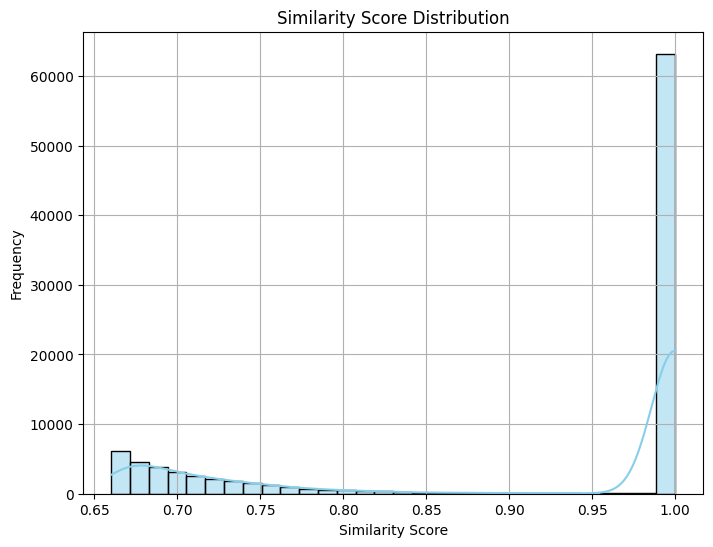


Cluster-wise Retained Pair Counts:
Cluster
1    62934
0    31776
3      118
2       67
Name: count, dtype: int64


<ipython-input-21-89c3d01935fd>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="viridis")


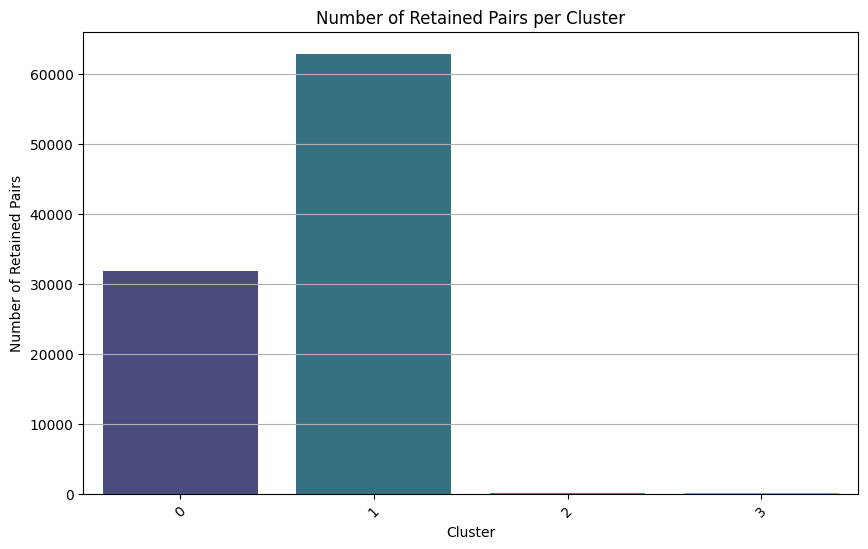


Top Cross-Domain Relationships:
                 Domain 1               Domain 2  Count
10       Machine Learning       Machine Learning  46356
5   Experimental workflow  Experimental workflow  16720
14             Microscopy       Machine Learning   7788
11       Machine Learning             Microscopy   6730
9        Machine Learning  Experimental workflow   3748
1           Computational  Experimental workflow   3717
0           Computational          Computational   2928
8        Machine Learning          Computational   1617
6   Experimental workflow       Machine Learning   1274
15             Microscopy             Microscopy   1042


<ipython-input-21-89c3d01935fd>:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


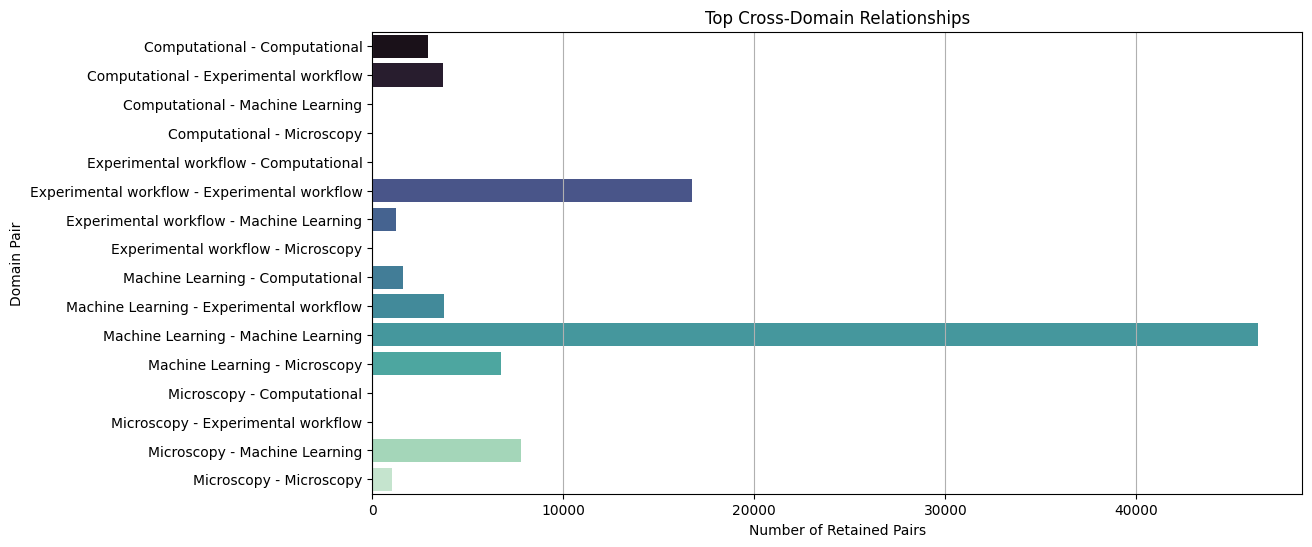


Top Cross-Ontology Relationships:
           Ontology 1        Ontology 2  Count
1            DMOP.owl          DMOP.owl  16295
21   EXPO04-19-06.owl  EXPO04-19-06.owl  13191
196    omeroriken.owl          DMOP.owl   4878
103        expose.owl          DMOP.owl   4503
129       mexalgo.owl          DMOP.owl   3362
16           DMOP.owl    omeroriken.owl   3283
143       mexcore.owl          DMOP.owl   3247
217  reproduce-me.owl  reproduce-me.owl   3019
9            DMOP.owl        expose.owl   2938
211  reproduce-me.owl  EXPO04-19-06.owl   2646


In [ ]:
# Load the cleaned similarity results
output_similarity_path = "Adjust OutputPath /filtered_similarity_scores_clusters.csv"
similarity_results = pd.read_csv(output_similarity_path)

# 1. Data Overview
print("Data Overview:")
print(f"Total Retained Pairs: {len(similarity_results)}")
print(f"Clusters Involved: {similarity_results['Cluster'].nunique()}")
print(f"Domains Involved: {similarity_results['Domain 1'].nunique()} - {similarity_results['Domain 2'].nunique()}")
print(f"Ontologies Involved: {similarity_results['Ontology 1'].nunique()} - {similarity_results['Ontology 2'].nunique()}")
print("\nSample of Retained Pairs:")
print(similarity_results.head())

# 2. Statistical Summary of Similarity Scores
print("\nStatistical Summary of Similarity Scores:")
print(similarity_results["Similarity Score"].describe())

# 3. Visualize Similarity Score Distribution
plt.figure(figsize=(8, 6))
sns.histplot(similarity_results["Similarity Score"], bins=30, kde=True, color="skyblue")
plt.title("Similarity Score Distribution")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# 4. Cluster-wise Analysis
print("\nCluster-wise Retained Pair Counts:")
cluster_counts = similarity_results["Cluster"].value_counts()
print(cluster_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="viridis")
plt.title("Number of Retained Pairs per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Retained Pairs")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.show()

# 5. Cross-Domain Analysis
cross_domain_counts = similarity_results.groupby(["Domain 1", "Domain 2"]).size().reset_index(name="Count")
cross_domain_counts = cross_domain_counts.sort_values("Count", ascending=False)

print("\nTop Cross-Domain Relationships:")
print(cross_domain_counts.head(10))

# Visualize cross-domain relationships
plt.figure(figsize=(12, 6))
sns.barplot(
    data=cross_domain_counts.head(10),
    x="Count",
    y=cross_domain_counts.apply(lambda x: f"{x['Domain 1']} - {x['Domain 2']}", axis=1),
    palette="mako"
)
plt.title("Top Cross-Domain Relationships")
plt.xlabel("Number of Retained Pairs")
plt.ylabel("Domain Pair")
plt.grid(True, axis="x")
plt.show()

# 6. Cross-Ontology Relationships
cross_ontology_counts = similarity_results.groupby(["Ontology 1", "Ontology 2"]).size().reset_index(name="Count")
cross_ontology_counts = cross_ontology_counts.sort_values("Count", ascending=False)

print("\nTop Cross-Ontology Relationships:")
print(cross_ontology_counts.head(10))

# **Using GPT4-o for Relationship Generation**

In [ ]:
# OpenAI API key
openai.api_key = "Add your Open AI key"

# Load the dataset
df = pd.read_csv("Adjust OutputPath /filtered_similarity_scores_clusters.csv")


# This part of the code is optional due to computational constraints you can either choose samples for the test or run the generation function for the overall dataset

# # Filter rows where Domain1 is "Machine Learning"
# machine_learning_rows = df[(df['Domain1'] == "Experimental workflow") & (df['Domain2'] == "Experimental workflow")]

# # Group by Domain1 and Domain2 and count occurrences
# domain_combinations = df.groupby(['Domain1', 'Domain2']).size().reset_index(name='Frequency')

# # Display the results
# print(domain_combinations)

# # Save the result to a CSV file (optional)
# output_path = 'domain_combinations_frequency.csv'
# domain_combinations.to_csv(output_path, index=False)
# print(f"Frequency analysis saved to {output_path}")

# # Group by combinations of Domain1 and Domain2
# grouped = df.groupby(['Domain1', 'Domain2'])

# # Number of samples per combination
# samples_per_group = 30  # Define the desired number of samples per group

# # Create an empty DataFrame to store the sampled rows
# uniform_sampled_df = pd.DataFrame()

# # Randomly sample rows from each group
# for name, group in grouped:
#     if len(group) >= samples_per_group:
#         sampled_group = group.sample(n=samples_per_group, random_state=42)  # Sample 20 rows if the group has enough rows
#     else:
#         sampled_group = group  # If the group has fewer rows, take all of them
#     uniform_sampled_df = pd.concat([uniform_sampled_df, sampled_group], ignore_index=True)

# # Save or inspect the sampled dataset
# uniform_sampled_df.to_csv('uniform_sampled_combinations.csv', index=False)
# print(f"Sampled dataset saved with {len(uniform_sampled_df)} rows.")

# # Pivot table for heatmap
# pivot_table = domain_combinations.pivot(index='Domain1', columns='Domain2', values='Frequency')

# # Plot heatmap
# plt.figure(figsize=(10, 8))
# sns.heatmap(pivot_table, annot=True, cmap='Blues', fmt='g')
# plt.title('Frequency of Domain1 to Domain2 Combinations')
# plt.xlabel('Domain2')
# plt.ylabel('Domain1')
# plt.show()

# # Bar chart of domain combinations
# plt.figure(figsize=(12, 6))
# sns.barplot(x='Domain1', y='Frequency', hue='Domain2', data=domain_combinations)
# plt.title('Frequency of Domain1 to Domain2 Combinations')
# plt.xlabel('Domain1')
# plt.ylabel('Frequency')
# plt.xticks(rotation=45)
# plt.legend(title='Domain2')
# plt.tight_layout()
# plt.show()


In [ ]:
# Function to generate relationships using GPT-4
def generate_relationship_gpt4(subject1, subject2, ontology_source1, ontology_source2, similarity_score):
    """
    Generate meaningful relationships between ontology concepts using GPT-4.

    Args:
        subject1 (str): Name of the first subject.
        subject2 (str): Name of the second subject.
        ontology_source1 (str): Ontology source for the first subject.
        ontology_source2 (str): Ontology source for the second subject.
        similarity_score (float): Cosine similarity score.

    Returns:
        dict: Generated relationship details including relationship, nature, type, source, target, justification, and reference.
    """
    # Define the task context and instructions
    messages = [
        {
            "role": "system",
            "content": """
                You are an expert in ontology construction and knowledge graph generation. Your task is to construct a network of meaningful relationships between concepts in the ReproduceMeON context.
                Use your semantic understanding and domain knowledge to decide if a link exists between the concepts. Do not solely rely on the similarity score. Instead, consider the conceptual roles, dependencies, and real-world interactions between the concepts.
                Follow these rules strictly:
                - Avoid vague relationships like "related to."
                - Ensure the relationships reflect meaningful, real-world dependencies.
                - Provide a justification sentence for why the relationship exists.
                - Cite a specific publication, book, or journal article to support your justification sentence.
            """
        },
        {
            "role": "user",
            "content": f"""
                ### Input Analysis:
                - Subject 1: {subject1}
                - Ontology Source 1: {ontology_source1}
                - Subject 2: {subject2}
                - Ontology Source 2: {ontology_source2}
                - Similarity Score: {similarity_score}

                ### Instructions:
                For the given input, make a reasoned judgment about whether a link exists between the two concepts. If a link exists, define:
                - Relationship: Semantic link describing the dependency (e.g., "enables," "requires").
                - Relationship Nature: One of [Hierarchical, Functional, Causal, Temporal, Spatial, Compositional, Comparative, Transformational, Instrumental].
                - Source: Subject initiating the relationship.
                - Target: Subject dependent on the relationship.
                - Justification Sentence: A clear explanation of why the relationship exists based on your reasoning and semantic understanding.
                - Scientific Reference: Provide a specific citation (publication, book, or journal article) to support your justification sentence.

                If no relationship exists, state "No Relationship" under the "Relationship" field and explain why in the "Justification Sentence."

                Return the result in this exact format:
                {{
                    "Relationship": "Semantic link or 'No Relationship'",
                    "Relationship Nature": "One of the predefined types or empty if no relationship exists",
                    "Source": "Subject1 or Subject2, or empty if no relationship exists",
                    "Target": "Subject1 or Subject2, or empty if no relationship exists",
                    "Justification Sentence": "Reasoned explanation of why the relationship exists or not",
                    "Scientific Reference": "Citation of the publication, book, or journal article"
                }}
            """
        }
    ]

    try:
        # Call GPT-4 API
        response = openai.ChatCompletion.create(
            model="gpt-4",
            messages=messages,
            max_tokens=400,  # Increased token limit to accommodate longer justifications and references
            temperature=0.2  # Reduce randomness for consistent outputs
        )

        # Parse the response content
        gpt_response = response["choices"][0]["message"]["content"].strip()
        result = eval(gpt_response)  # Convert string to dict

        # Ensure all keys exist in the result, even if empty
        return {
            "Relationship": result.get("Relationship", ""),
            "Relationship Nature": result.get("Relationship Nature", ""),
            "Source": result.get("Source", ""),
            "Target": result.get("Target", ""),
            "Justification Sentence": result.get("Justification Sentence", ""),
            "Scientific Reference": result.get("Scientific Reference", ""),
        }
    except Exception as e:
        # Return defaults in case of errors
        return {
            "Relationship": f"Error: {e}",
            "Relationship Nature": "",
            "Source": "",
            "Target": "",
            "Justification Sentence": "",
            "Scientific Reference": "",
        }

# Apply the function to generate relationships
def process_row(row):
    return pd.Series(generate_relationship_gpt4(
        row['subject1'],
        row['subject2'],
        row.get('ontology_source1', ''),
        row.get('ontology_source2', ''),
        row.get('similarity_score', 0)
    ))

# Apply the function to generate relationships
uniform_sampled_df = uniform_sampled_df.copy()  # Ensure it's a copy
uniform_sampled_df[['Relationship', 'Relationship Nature', 'Source', 'Target', 'Justification Sentence', 'Scientific Reference']] = uniform_sampled_df.apply(process_row, axis=1)
# Save results to a CSV file
output_file = 'relationships_output_gpt4_with_references.csv'
uniform_sampled_df.to_csv(output_file, index=False)
print(f"Relationships generated and saved to {output_file}")